In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

print("Imports OK")

Imports OK


In [2]:
cwd = Path.cwd().resolve()

if (cwd / "data").exists():
    ROOT = cwd
elif (cwd.parent / "data").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"No encontré la carpeta 'data' ni en {cwd} ni en {cwd.parent}"
    )

paths = {
    "diagnostico_inicial": ROOT / "data/08_reporting/diagnostico_inicial.csv",
    "comparacion_limpieza": ROOT / "data/08_reporting/comparacion_limpieza.csv",
    "dataset_universitario": ROOT / "data/03_primary/dataset_universitario.csv",
    "dataset_universitario_modelo": ROOT / "data/04_feature/dataset_universitario_modelo.csv",
    "resumen_asignaturas": ROOT / "data/08_reporting/resumen_asignaturas.csv",
    "auditoria_datasets": ROOT / "data/08_reporting/auditoria_datasets.csv",
    "reporte_validacion": ROOT / "data/08_reporting/reporte_validacion.json",
}

print("ROOT detectado:", ROOT)
for name, path in paths.items():
    print(f"{name}: {'OK' if path.exists() else 'NO ENCONTRADO'} -> {path}")

ROOT detectado: C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial
diagnostico_inicial: OK -> C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\08_reporting\diagnostico_inicial.csv
comparacion_limpieza: OK -> C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\08_reporting\comparacion_limpieza.csv
dataset_universitario: OK -> C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\03_primary\dataset_universitario.csv
dataset_universitario_modelo: OK -> C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\04_feature\dataset_universitario_modelo.csv
resumen_asignaturas: OK -> C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\08_reporting\resumen_asignaturas.csv
auditoria_datasets: OK -> C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\08_reporting\auditoria_datasets.csv
reporte_validacion: OK -> C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\08_reporting\reporte_validacion.json


In [3]:
diagnostico_inicial = pd.read_csv(paths["diagnostico_inicial"], encoding="latin1")
comparacion_limpieza = pd.read_csv(paths["comparacion_limpieza"], encoding="latin1")
dataset_universitario = pd.read_csv(paths["dataset_universitario"], encoding="latin1")
dataset_universitario_modelo = pd.read_csv(paths["dataset_universitario_modelo"], encoding="latin1")
resumen_asignaturas = pd.read_csv(paths["resumen_asignaturas"], encoding="latin1")
auditoria_datasets = pd.read_csv(paths["auditoria_datasets"], encoding="latin1")

with open(paths["reporte_validacion"], "r", encoding="utf-8") as f:
    reporte_validacion = json.load(f)

print("Carga completada")

Carga completada


In [4]:
print("=== diagnostico_inicial ===")
display(diagnostico_inicial.head())

print("=== comparacion_limpieza ===")
display(comparacion_limpieza)

print("=== dataset_universitario ===")
display(dataset_universitario.head())

print("=== resumen_asignaturas ===")
display(resumen_asignaturas.head())

print("=== auditoria_datasets ===")
display(auditoria_datasets)

=== diagnostico_inicial ===


,dataset,filas,columnas,nulos_totales,duplicados_exactos,columnas_con_nulos,checksum,tipo_registro,columna,dtype,nulos,porcentaje_nulos,valores_unicos,muestra
0,estudiantes_raw,360.0,8.0,145.0,10.0,8.0,7cef584c4e5f044d774008270bad567852b645ed9919b7...,resumen,NaN,NaN,NaN,NaN,NaN,NaN
1,inscripciones_raw,927.0,8.0,367.0,27.0,8.0,4477a5a20b7e43d932159b2167b3569ca0e21e8e568500...,resumen,NaN,NaN,NaN,NaN,NaN,NaN
2,calificaciones_raw,721.0,7.0,245.0,21.0,7.0,72e2eca2f8df50c1704ac3873d132dd031ab2b5d77923a...,resumen,NaN,NaN,NaN,NaN,NaN,NaN
3,asistencia_raw,618.0,5.0,147.0,18.0,5.0,051cc339c6d5d0d6d733fe7cfae6a12a394da8a3c28d55...,resumen,NaN,NaN,NaN,NaN,NaN,NaN
4,estudiantes_raw,NaN,NaN,NaN,NaN,NaN,NaN,detalle_columna,id_estudiante,float64,14.0,3.89,337.0,"1.0, 3.0, 4.0"


=== comparacion_limpieza ===


,dataset,filas_raw,filas_clean,nulos_raw,nulos_clean,duplicados_raw,duplicados_clean,filas_eliminadas
0,estudiantes,360,337,145,0,10,0,23
1,inscripciones,927,828,367,0,27,0,99
2,calificaciones,721,639,245,0,21,0,82
3,asistencia,618,544,147,0,18,0,74


=== dataset_universitario ===


,id_inscripcion,id_estudiante,codigo_asignatura,nombre_asignatura,seccion,semestre,anio,docente,nombre,rut,carrera,sede,anio_ingreso,email,estado_matricula,nota_promedio,nota_minima,nota_maxima,cantidad_evaluaciones,ponderacion_total,nota_final_ponderada,total_clases,presentes,ausentes,justificados,tardanzas,tasa_asistencia,carga_asignaturas,antiguedad_ingreso,resultado_academico,riesgo_academico,aprobado
0,314,7,ASG-649,Quimica,002D,1,2022,Docente No Informado,Tomas Espinoza Castro,12491053-5,Ing. Informatica,Santiago Centro,2021,sin_email_7@correo.local,Regular,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1,1,Critico,Alto,0
1,739,8,ASG-422,Redes,001D,1,2022,Joaquin Flores Gatica,Barbara Tapia Tapia,14071893-7,Derecho,Santiago Centro,2021,barbara.tapia@outlook.com,Regular,6.6,6.6,6.6,1.0,10.0,6.6,0.0,0.0,0.0,0.0,0.0,0.0,1,1,Sobresaliente,Alto,1
2,450,9,ASG-793,Calculo I,001D,1,2022,Francisca Garcia Jara,Benjamin Gatica Medina,15369011-1,Ing. Informatica,Santiago Centro,2021,benjamin.gatica@gmail.com,Regular,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1,1,Critico,Alto,0
3,270,10,ASG-625,Contabilidad,001D,1,2022,Javiera Aguilera Vergara,Jose Araya Contreras,18203934-8,Arquitectura,Sede Norte,2024,jose.araya@outlook.com,Regular,2.5,2.5,2.5,1.0,10.0,2.5,0.0,0.0,0.0,0.0,0.0,0.0,1,0,Critico,Alto,0
4,58,13,ASG-285,Fisica,002D,1,2022,Daniela Fuentes Valenzuela,Nicolas Valenzuela Soto,15538568-2,Ing. Informatica,Sede Norte,2021,nicolas.valenzuela@gmail.com,Regular,5.1,5.1,5.1,1.0,30.0,5.1,1.0,1.0,0.0,0.0,0.0,1.0,1,1,Aceptable,Bajo,1


=== resumen_asignaturas ===


,anio,semestre,nombre_asignatura,estudiantes_inscritos,nota_final_promedio,asistencia_promedio,tasa_aprobacion
0,2022,1,Redes,8,4.47,0.5000,0.6250
1,2022,1,Fisica,6,3.00,0.4167,0.5000
2,2022,1,Etica,9,2.52,0.2222,0.4444
3,2022,1,Ingles,5,1.92,0.2000,0.4000
4,2022,1,Marketing,8,3.03,0.2500,0.3750


=== auditoria_datasets ===


,dataset,filas,columnas,nulos_totales,duplicados_exactos,columnas_con_nulos,checksum
0,estudiantes_raw,360,8,145,10,8,7cef584c4e5f044d774008270bad567852b645ed9919b7...
1,inscripciones_raw,927,8,367,27,8,4477a5a20b7e43d932159b2167b3569ca0e21e8e568500...
2,calificaciones_raw,721,7,245,21,7,72e2eca2f8df50c1704ac3873d132dd031ab2b5d77923a...
3,asistencia_raw,618,5,147,18,5,051cc339c6d5d0d6d733fe7cfae6a12a394da8a3c28d55...
4,estudiantes_clean,337,8,0,0,0,3276a568cc09bb43ed49c50477a6e748ae49aa4a4a57a8...
5,inscripciones_clean,828,8,0,0,0,e331a3df6cb1d3e64bcdac4da6cc627c61acb56d49d260...
6,calificaciones_clean,639,7,0,0,0,07cb9a3c58f14b8f1ee43db8d18cb8e8fa023c1c50cc5c...
7,asistencia_clean,544,5,0,0,0,f49be97d27b33a40a2c6a5228affbf88129ffbb67a76b1...
8,dataset_universitario,795,32,0,0,0,b5dae004c21d7e11327940492b69716284050efd348c16...
9,dataset_universitario_modelo,795,78,0,0,0,00197984994eb4ca125a226d66889ebdc4f6f0c1ffb515...


In [5]:
print("Shape dataset_universitario:", dataset_universitario.shape)

print("\nColumnas:")
display(pd.DataFrame({"columna": dataset_universitario.columns}))

print("\nTipos de datos:")
display(
    dataset_universitario.dtypes.astype(str)
    .reset_index()
    .rename(columns={"index": "columna", 0: "dtype"})
)

Shape dataset_universitario: (795, 32)

Columnas:


,columna
0,id_inscripcion
1,id_estudiante
2,codigo_asignatura
3,nombre_asignatura
4,seccion
5,semestre
6,anio
7,docente
8,nombre
9,rut



Tipos de datos:


,columna,dtype
0,id_inscripcion,int64
1,id_estudiante,int64
2,codigo_asignatura,str
3,nombre_asignatura,str
4,seccion,str
5,semestre,int64
6,anio,int64
7,docente,str
8,nombre,str
9,rut,str


In [6]:
print("=== Estadisticas numericas ===")
display(dataset_universitario.describe(include=[np.number]).T)

print("=== Estadisticas categoricas ===")
display(dataset_universitario.describe(include=["object"]).T)

=== Estadisticas numericas ===


,count,mean,std,min,25%,50%,75%,max
id_inscripcion,795.0,447.815094,260.526631,1.0,223.5,444.0,669.50,900.0
id_estudiante,795.0,176.817610,100.224412,1.0,89.0,181.0,259.50,350.0
semestre,795.0,1.566038,0.495932,1.0,1.0,2.0,2.00,2.0
anio,795.0,2023.020126,0.780491,2022.0,2022.0,2023.0,2024.00,2024.0
anio_ingreso,795.0,2021.415094,1.621261,2019.0,2020.0,2021.0,2023.00,2024.0
nota_promedio,795.0,2.142658,2.321755,0.0,0.0,1.5,4.00,7.0
nota_minima,795.0,1.982013,2.240680,0.0,0.0,1.2,3.90,7.0
nota_maxima,795.0,2.303145,2.492786,0.0,0.0,1.5,4.55,7.0
cantidad_evaluaciones,795.0,0.710692,0.801022,0.0,0.0,1.0,1.00,5.0
ponderacion_total,795.0,17.893082,22.226392,0.0,0.0,10.0,35.00,140.0


=== Estadisticas categoricas ===


                    WARNING  C:\Users\madzm\AppData\Local\Temp\ipykernel_11204\2118943856.py:5:     ]8;id=624889;file://C:\Users\madzm\AppData\Roaming\uv\python\cpython-3.13-windows-x86_64-none\Lib\warnings.py\warnings.py]8;;\:]8;id=277985;file://C:\Users\madzm\AppData\Roaming\uv\python\cpython-3.13-windows-x86_64-none\Lib\warnings.py#110\110]8;;\
                             Pandas4Warning: For backward compatibility, 'str' dtypes are included                 
                             by select_dtypes when 'object' dtype is specified. This behavior is                   
                             deprecated and will be removed in a future version. Explicitly pass                   
                             'str' to `include` to select them, or to `exclude` to remove them and                 
                             silence this warning.                                                                 
                             See                                                                                   
                             https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#str                
                             ing-migration-select-dtypes for details on how to write code that                     
                             works with pandas 2 and 3.                                                            
                               display(dataset_universitario.describe(include=["object"]).T)                       
                                                                                                                   

,count,unique,top,freq
codigo_asignatura,795,522,ASG-SINCOD,38
nombre_asignatura,795,12,Algoritmos,118
seccion,795,4,001V,239
docente,795,758,Docente No Informado,32
nombre,795,284,Sin Nombre,41
rut,795,290,SIN-RUT,29
carrera,795,7,Psicologia,171
sede,795,5,Sede Sur,219
email,795,286,barbara.tapia@outlook.com,9
estado_matricula,795,4,Regular,559


In [7]:
diag_resumen = diagnostico_inicial[diagnostico_inicial["tipo_registro"] == "resumen"].copy()
diag_detalle = diagnostico_inicial[diagnostico_inicial["tipo_registro"] == "detalle_columna"].copy()

print("=== Resumen global por tabla raw ===")
display(
    diag_resumen[
        ["dataset", "filas", "columnas", "nulos_totales", "duplicados_exactos", "columnas_con_nulos"]
    ]
)

print("=== Top columnas con mas nulos ===")
detalle_nulos = diag_detalle.sort_values("nulos", ascending=False)[
    ["dataset", "columna", "dtype", "nulos", "porcentaje_nulos"]
]
display(detalle_nulos.head(20))

=== Resumen global por tabla raw ===


,dataset,filas,columnas,nulos_totales,duplicados_exactos,columnas_con_nulos
0,estudiantes_raw,360.0,8.0,145.0,10.0,8.0
1,inscripciones_raw,927.0,8.0,367.0,27.0,8.0
2,calificaciones_raw,721.0,7.0,245.0,21.0,7.0
3,asistencia_raw,618.0,5.0,147.0,18.0,5.0


=== Top columnas con mas nulos ===


,dataset,columna,dtype,nulos,porcentaje_nulos
17,inscripciones_raw,semestre,float64,61.0,6.58
18,inscripciones_raw,año,float64,50.0,5.39
16,inscripciones_raw,seccion,str,47.0,5.07
15,inscripciones_raw,nombre_asignatura,str,45.0,4.85
25,calificaciones_raw,ponderacion,float64,44.0,6.10
14,inscripciones_raw,codigo_asignatura,str,44.0,4.75
19,inscripciones_raw,docente,str,43.0,4.64
24,calificaciones_raw,nota,str,41.0,5.69
12,inscripciones_raw,id_inscripcion,float64,40.0,4.31
13,inscripciones_raw,id_estudiante,float64,37.0,3.99


In [8]:
comparacion_limpieza["pct_reduccion_nulos"] = np.where(
    comparacion_limpieza["nulos_raw"] > 0,
    ((comparacion_limpieza["nulos_raw"] - comparacion_limpieza["nulos_clean"]) / comparacion_limpieza["nulos_raw"]) * 100,
    0
).round(2)

comparacion_limpieza["pct_reduccion_duplicados"] = np.where(
    comparacion_limpieza["duplicados_raw"] > 0,
    ((comparacion_limpieza["duplicados_raw"] - comparacion_limpieza["duplicados_clean"]) / comparacion_limpieza["duplicados_raw"]) * 100,
    0
).round(2)

display(comparacion_limpieza)

,dataset,filas_raw,filas_clean,nulos_raw,nulos_clean,duplicados_raw,duplicados_clean,filas_eliminadas,pct_reduccion_nulos,pct_reduccion_duplicados
0,estudiantes,360,337,145,0,10,0,23,100.0,100.0
1,inscripciones,927,828,367,0,27,0,99,100.0,100.0
2,calificaciones,721,639,245,0,21,0,82,100.0,100.0
3,asistencia,618,544,147,0,18,0,74,100.0,100.0


In [9]:
nulos_finales = (
    dataset_universitario.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "columna", 0: "nulos"})
    .sort_values("nulos", ascending=False)
)

nulos_finales["porcentaje"] = (nulos_finales["nulos"] / len(dataset_universitario) * 100).round(2)

display(nulos_finales.head(30))

,columna,nulos,porcentaje
0,id_inscripcion,0,0.0
1,id_estudiante,0,0.0
2,codigo_asignatura,0,0.0
3,nombre_asignatura,0,0.0
4,seccion,0,0.0
5,semestre,0,0.0
6,anio,0,0.0
7,docente,0,0.0
8,nombre,0,0.0
9,rut,0,0.0


In [10]:
duplicados_finales = dataset_universitario.duplicated().sum()
duplicados_id_inscripcion = dataset_universitario["id_inscripcion"].duplicated().sum()

print("Duplicados exactos del dataset final:", duplicados_finales)
print("Duplicados por id_inscripcion:", duplicados_id_inscripcion)

print("\n=== Auditoria de datasets ===")
display(auditoria_datasets)

Duplicados exactos del dataset final: 0
Duplicados por id_inscripcion: 0

=== Auditoria de datasets ===


,dataset,filas,columnas,nulos_totales,duplicados_exactos,columnas_con_nulos,checksum
0,estudiantes_raw,360,8,145,10,8,7cef584c4e5f044d774008270bad567852b645ed9919b7...
1,inscripciones_raw,927,8,367,27,8,4477a5a20b7e43d932159b2167b3569ca0e21e8e568500...
2,calificaciones_raw,721,7,245,21,7,72e2eca2f8df50c1704ac3873d132dd031ab2b5d77923a...
3,asistencia_raw,618,5,147,18,5,051cc339c6d5d0d6d733fe7cfae6a12a394da8a3c28d55...
4,estudiantes_clean,337,8,0,0,0,3276a568cc09bb43ed49c50477a6e748ae49aa4a4a57a8...
5,inscripciones_clean,828,8,0,0,0,e331a3df6cb1d3e64bcdac4da6cc627c61acb56d49d260...
6,calificaciones_clean,639,7,0,0,0,07cb9a3c58f14b8f1ee43db8d18cb8e8fa023c1c50cc5c...
7,asistencia_clean,544,5,0,0,0,f49be97d27b33a40a2c6a5228affbf88129ffbb67a76b1...
8,dataset_universitario,795,32,0,0,0,b5dae004c21d7e11327940492b69716284050efd348c16...
9,dataset_universitario_modelo,795,78,0,0,0,00197984994eb4ca125a226d66889ebdc4f6f0c1ffb515...


In [11]:
print("=== Row counts ===")
display(pd.DataFrame([reporte_validacion["row_counts"]]))

print("=== Integrity validation ===")
display(pd.DataFrame([reporte_validacion["integrity_validation"]]))

schema_validation_df = (
    pd.DataFrame(reporte_validacion["schema_validation"])
    .T
    .reset_index()
    .rename(columns={"index": "columna"})
)

print("=== Schema validation ===")
display(schema_validation_df)

print("Columnas con esquema NO coincidente:")
display(schema_validation_df[schema_validation_df["coincide"] == False])

=== Row counts ===


,estudiantes_clean,inscripciones_clean,calificaciones_clean,asistencia_clean,dataset_universitario
0,337,828,639,544,795


=== Integrity validation ===


,inscripciones_sin_estudiante,calificaciones_sin_inscripcion,asistencia_sin_inscripcion,dataset_ids_inscripcion_duplicados,dataset_nulos_totales
0,33,50,41,0,0


=== Schema validation ===


,columna,esperado,real,coincide
0,id_inscripcion,Int64,int64,False
1,id_estudiante,Int64,int64,False
2,codigo_asignatura,string,str,False
3,nombre_asignatura,string,str,False
4,seccion,string,str,False
5,semestre,Int64,int64,False
6,anio,Int64,int64,False
7,docente,string,str,False
8,nombre,string,str,False
9,rut,string,str,False


Columnas con esquema NO coincidente:


,columna,esperado,real,coincide
0,id_inscripcion,Int64,int64,False
1,id_estudiante,Int64,int64,False
2,codigo_asignatura,string,str,False
3,nombre_asignatura,string,str,False
4,seccion,string,str,False
5,semestre,Int64,int64,False
6,anio,Int64,int64,False
7,docente,string,str,False
8,nombre,string,str,False
9,rut,string,str,False


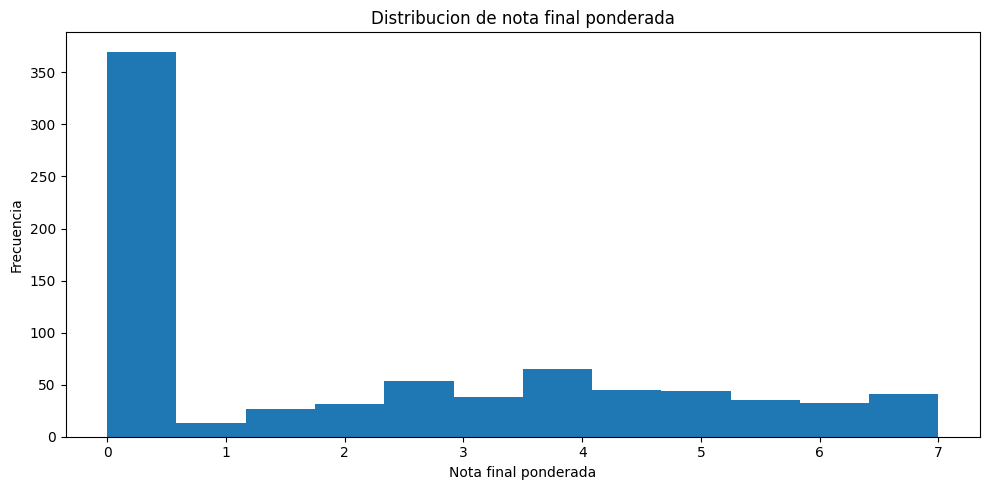

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(dataset_universitario["nota_final_ponderada"].dropna(), bins=12)
plt.title("Distribucion de nota final ponderada")
plt.xlabel("Nota final ponderada")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

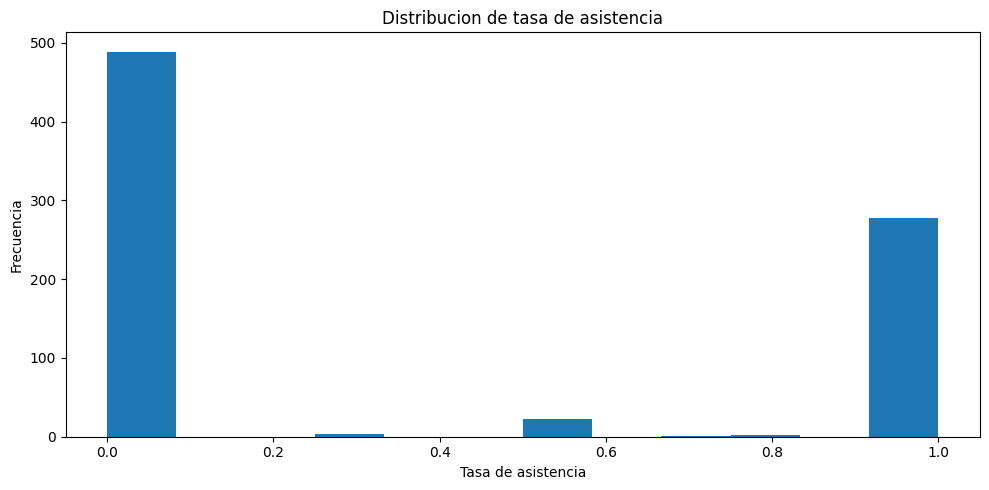

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(dataset_universitario["tasa_asistencia"].dropna(), bins=12)
plt.title("Distribucion de tasa de asistencia")
plt.xlabel("Tasa de asistencia")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

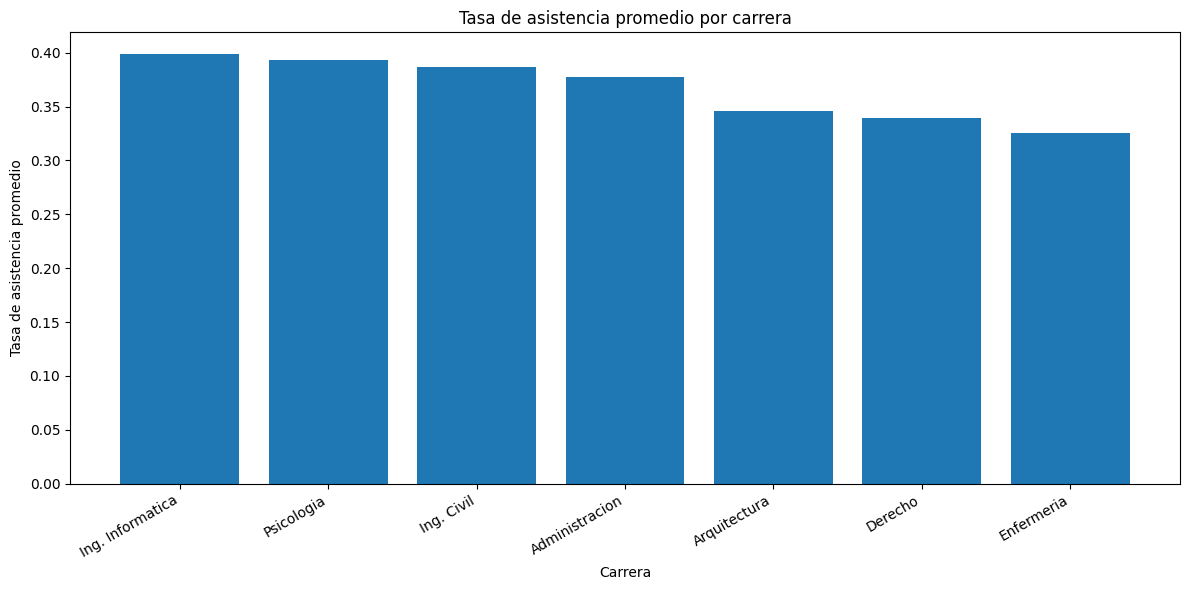

,carrera,tasa_asistencia
5,Ing. Informatica,0.398936
6,Psicologia,0.393275
4,Ing. Civil,0.387097
0,Administracion,0.377273
1,Arquitectura,0.345614
2,Derecho,0.339130
3,Enfermeria,0.325498


In [14]:
asistencia_por_carrera = (
    dataset_universitario
    .groupby("carrera", as_index=False)["tasa_asistencia"]
    .mean()
    .sort_values("tasa_asistencia", ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(asistencia_por_carrera["carrera"], asistencia_por_carrera["tasa_asistencia"])
plt.title("Tasa de asistencia promedio por carrera")
plt.xlabel("Carrera")
plt.ylabel("Tasa de asistencia promedio")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(asistencia_por_carrera)

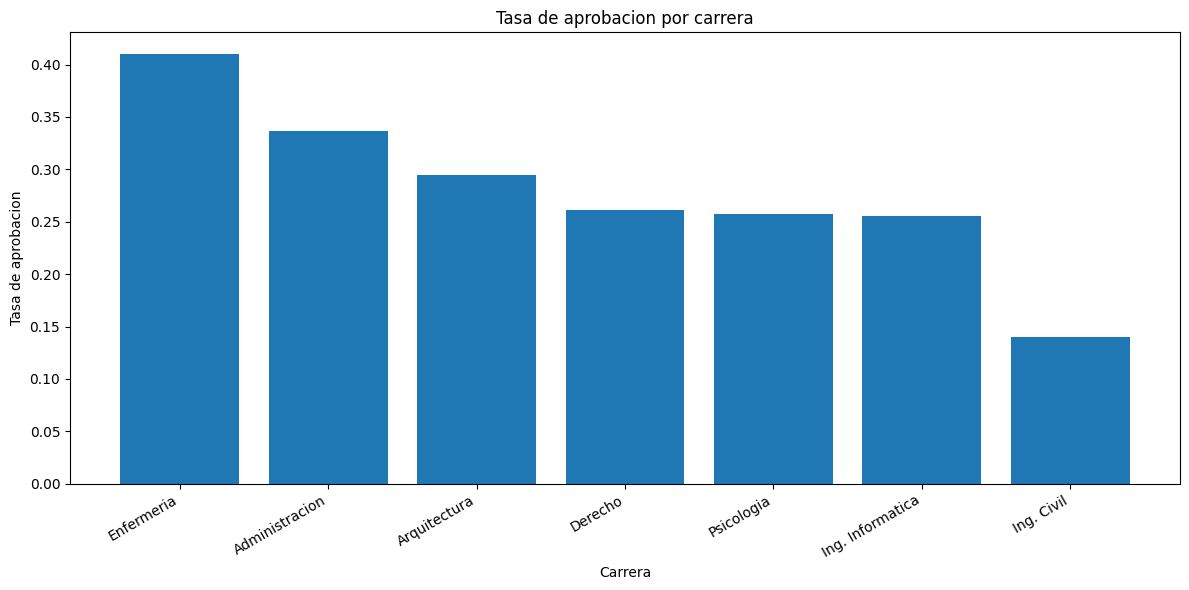

,carrera,aprobado
3,Enfermeria,0.4103
0,Administracion,0.3364
1,Arquitectura,0.2947
2,Derecho,0.2609
6,Psicologia,0.2573
5,Ing. Informatica,0.2553
4,Ing. Civil,0.1398


In [15]:
aprobacion_por_carrera = (
    dataset_universitario
    .groupby("carrera", as_index=False)["aprobado"]
    .mean()
    .sort_values("aprobado", ascending=False)
)

aprobacion_por_carrera["aprobado"] = aprobacion_por_carrera["aprobado"].round(4)

plt.figure(figsize=(12, 6))
plt.bar(aprobacion_por_carrera["carrera"], aprobacion_por_carrera["aprobado"])
plt.title("Tasa de aprobacion por carrera")
plt.xlabel("Carrera")
plt.ylabel("Tasa de aprobacion")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(aprobacion_por_carrera)

In [16]:
top_aprobacion = resumen_asignaturas.sort_values("tasa_aprobacion", ascending=False).head(10)
bottom_aprobacion = resumen_asignaturas.sort_values("tasa_aprobacion", ascending=True).head(10)

print("=== Top 10 asignaturas con mejor tasa de aprobacion ===")
display(top_aprobacion)

print("=== Top 10 asignaturas con peor tasa de aprobacion ===")
display(bottom_aprobacion)

=== Top 10 asignaturas con mejor tasa de aprobacion ===


,anio,semestre,nombre_asignatura,estudiantes_inscritos,nota_final_promedio,asistencia_promedio,tasa_aprobacion
0,2022,1,Redes,8,4.47,0.5000,0.6250
36,2023,2,Estadistica,9,3.50,0.4444,0.5556
60,2024,2,Estadistica,13,3.53,0.4286,0.5000
1,2022,1,Fisica,6,3.00,0.4167,0.5000
48,2024,1,Quimica,4,2.94,0.3750,0.5000
61,2024,2,Etica,8,2.70,0.5000,0.5000
2,2022,1,Etica,9,2.52,0.2222,0.4444
49,2024,1,Marketing,7,2.09,0.5714,0.4286
3,2022,1,Ingles,5,1.92,0.2000,0.4000
37,2023,2,Quimica,10,2.59,0.4000,0.4000


=== Top 10 asignaturas con peor tasa de aprobacion ===


,anio,semestre,nombre_asignatura,estudiantes_inscritos,nota_final_promedio,asistencia_promedio,tasa_aprobacion
11,2022,1,Estadistica,5,0.72,0.2000,0.0000
23,2022,2,Ingles,4,0.48,0.5000,0.0000
58,2024,1,Contabilidad,4,0.75,0.2500,0.0000
59,2024,1,Ingles,7,0.60,0.2857,0.0000
47,2023,2,Marketing,14,0.92,0.4286,0.0714
35,2023,1,Marketing,11,0.75,0.3182,0.0909
10,2022,1,Contabilidad,11,1.19,0.5909,0.0909
22,2022,2,Marketing,9,1.72,0.3000,0.1000
57,2024,1,Etica,10,0.97,0.4000,0.1000
34,2023,1,Fisica,9,1.19,0.4444,0.1111


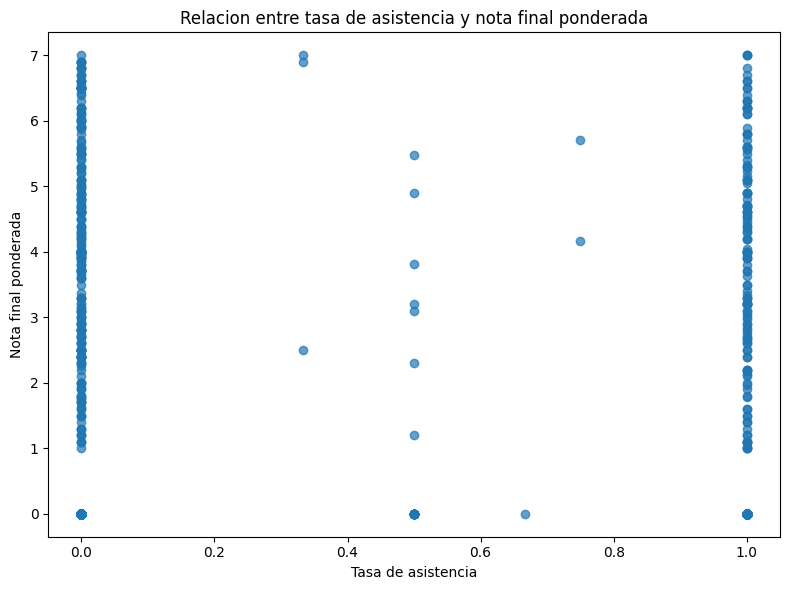

Correlacion:


,tasa_asistencia,nota_final_ponderada
tasa_asistencia,1.000000,-0.029541
nota_final_ponderada,-0.029541,1.000000


In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(
    dataset_universitario["tasa_asistencia"],
    dataset_universitario["nota_final_ponderada"],
    alpha=0.7
)
plt.title("Relacion entre tasa de asistencia y nota final ponderada")
plt.xlabel("Tasa de asistencia")
plt.ylabel("Nota final ponderada")
plt.tight_layout()
plt.show()

corr = dataset_universitario[["tasa_asistencia", "nota_final_ponderada"]].corr()
print("Correlacion:")
display(corr)

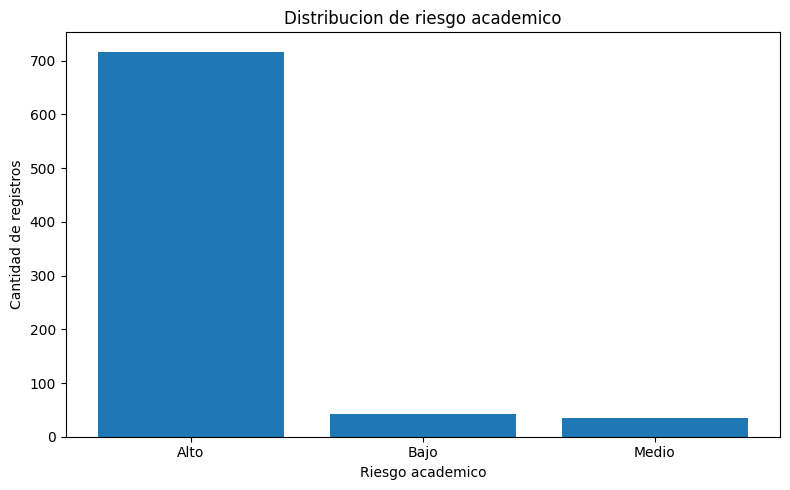

,riesgo_academico,cantidad
0,Alto,717
1,Bajo,43
2,Medio,35


In [18]:
riesgo_resumen = (
    dataset_universitario["riesgo_academico"]
    .value_counts(dropna=False)
    .reset_index()
)
riesgo_resumen.columns = ["riesgo_academico", "cantidad"]

plt.figure(figsize=(8, 5))
plt.bar(riesgo_resumen["riesgo_academico"], riesgo_resumen["cantidad"])
plt.title("Distribucion de riesgo academico")
plt.xlabel("Riesgo academico")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

display(riesgo_resumen)

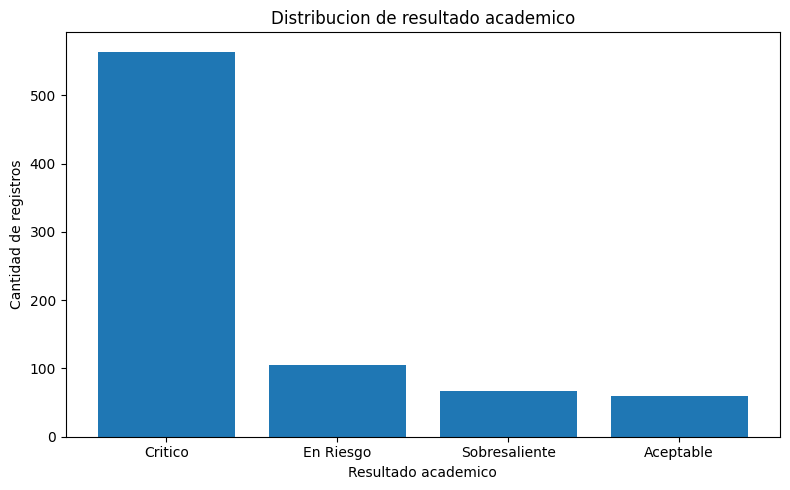

,resultado_academico,cantidad
0,Critico,564
1,En Riesgo,105
2,Sobresaliente,67
3,Aceptable,59


In [19]:
resultado_resumen = (
    dataset_universitario["resultado_academico"]
    .value_counts(dropna=False)
    .reset_index()
)
resultado_resumen.columns = ["resultado_academico", "cantidad"]

plt.figure(figsize=(8, 5))
plt.bar(resultado_resumen["resultado_academico"], resultado_resumen["cantidad"])
plt.title("Distribucion de resultado academico")
plt.xlabel("Resultado academico")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

display(resultado_resumen)

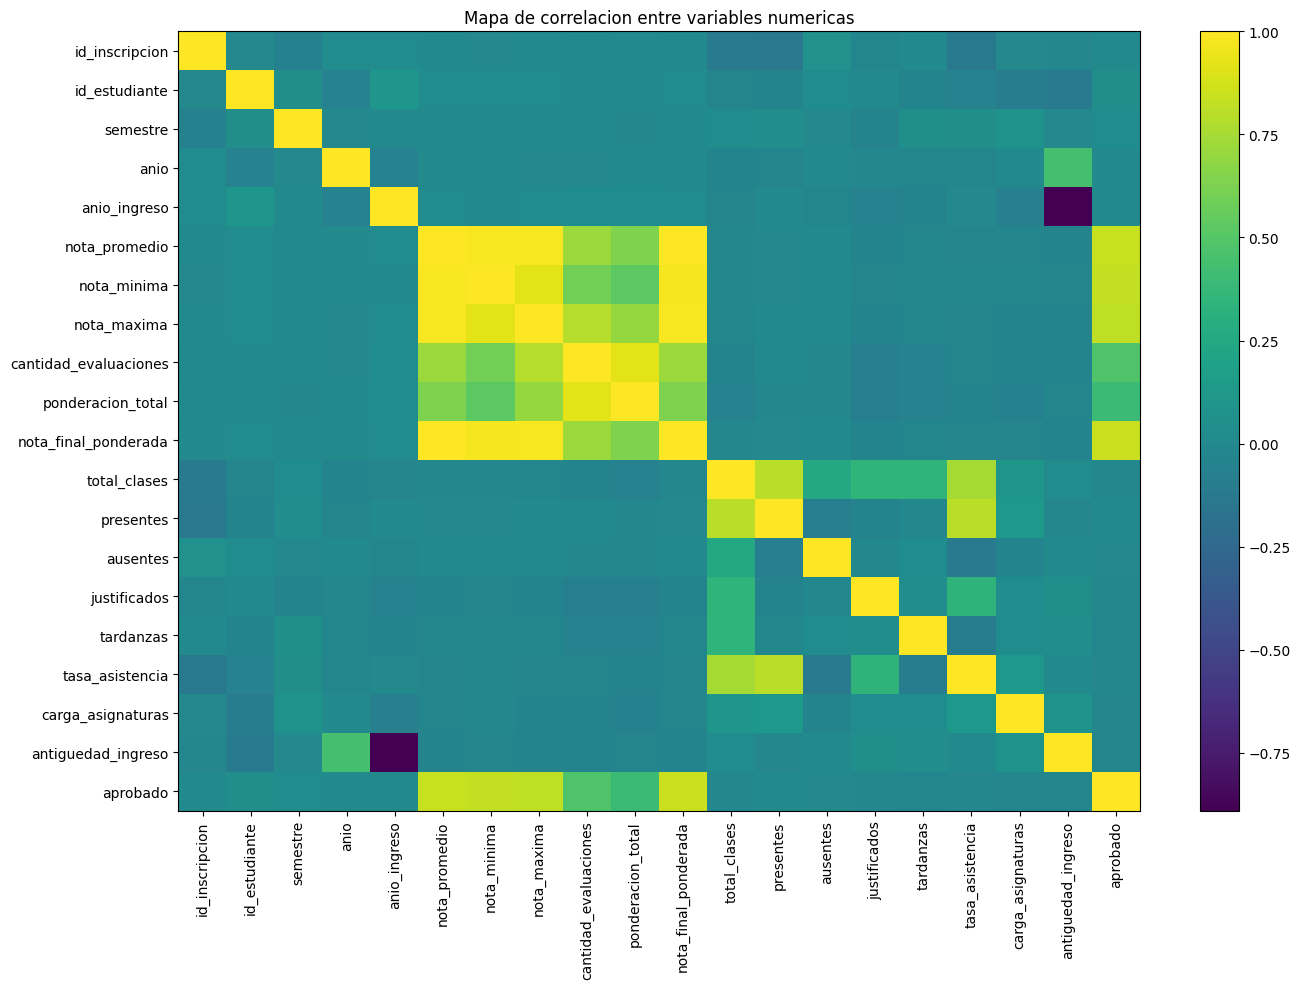

In [20]:
numeric_cols = dataset_universitario.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = dataset_universitario[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
im = plt.imshow(corr_matrix, aspect="auto")
plt.title("Mapa de correlacion entre variables numericas")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [21]:
total_registros = len(dataset_universitario)
tasa_aprobacion_global = dataset_universitario["aprobado"].mean().round(4)
asistencia_promedio_global = dataset_universitario["tasa_asistencia"].mean().round(4)
nota_promedio_global = dataset_universitario["nota_final_ponderada"].mean().round(2)

carrera_mejor_asistencia = asistencia_por_carrera.iloc[0]["carrera"]
valor_mejor_asistencia = round(asistencia_por_carrera.iloc[0]["tasa_asistencia"], 4)

carrera_mejor_aprobacion = aprobacion_por_carrera.iloc[0]["carrera"]
valor_mejor_aprobacion = round(aprobacion_por_carrera.iloc[0]["aprobado"], 4)

asignatura_mayor_aprobacion = top_aprobacion.iloc[0]["nombre_asignatura"]
asignatura_menor_aprobacion = bottom_aprobacion.iloc[0]["nombre_asignatura"]

print(f"""
RESUMEN EJECUTIVO

- El dataset final integrado contiene {total_registros} registros.
- La nota final ponderada promedio es {nota_promedio_global}.
- La tasa de asistencia promedio global es {asistencia_promedio_global}.
- La tasa de aprobacion global es {tasa_aprobacion_global}.
- La carrera con mejor asistencia promedio es {carrera_mejor_asistencia} ({valor_mejor_asistencia}).
- La carrera con mejor tasa de aprobacion es {carrera_mejor_aprobacion} ({valor_mejor_aprobacion}).
- La asignatura con mejor tasa de aprobacion es {asignatura_mayor_aprobacion}.
- La asignatura con peor tasa de aprobacion es {asignatura_menor_aprobacion}.
""")


RESUMEN EJECUTIVO

- El dataset final integrado contiene 795 registros.
- La nota final ponderada promedio es 2.15.
- La tasa de asistencia promedio global es 0.3675.
- La tasa de aprobacion global es 0.2818.
- La carrera con mejor asistencia promedio es Ing. Informatica (0.3989).
- La carrera con mejor tasa de aprobacion es Enfermeria (0.4103).
- La asignatura con mejor tasa de aprobacion es Redes.
- La asignatura con peor tasa de aprobacion es Estadistica.



CONCLUSIONES

1. El flujo Kedro permitió transformar los datos crudos en un dataset final reproducible y validado.
2. La etapa de limpieza redujo nulos, eliminó duplicados y estandarizó formatos inconsistentes.
3. La integración entre estudiantes, inscripciones, calificaciones y asistencia permitió construir variables derivadas relevantes.
4. La asistencia muestra relación con el rendimiento académico, por lo que es una variable explicativa importante.
5. La clasificación de riesgo académico facilita identificar grupos que requieren seguimiento.
6. La validación del esquema, integridad y auditoría refuerza la confiabilidad del resultado final.


In [23]:
eda_outputs = ROOT / "data/08_reporting/eda_outputs"
eda_outputs.mkdir(parents=True, exist_ok=True)

asistencia_por_carrera.to_csv(eda_outputs / "asistencia_por_carrera.csv", index=False, encoding="latin1")
aprobacion_por_carrera.to_csv(eda_outputs / "aprobacion_por_carrera.csv", index=False, encoding="latin1")
riesgo_resumen.to_csv(eda_outputs / "riesgo_resumen.csv", index=False, encoding="latin1")
resultado_resumen.to_csv(eda_outputs / "resultado_resumen.csv", index=False, encoding="latin1")
nulos_finales.to_csv(eda_outputs / "nulos_finales.csv", index=False, encoding="latin1")
schema_validation_df.to_csv(eda_outputs / "schema_validation.csv", index=False, encoding="latin1")

print("Tablas EDA guardadas en:", eda_outputs)

Tablas EDA guardadas en: C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\08_reporting\eda_outputs


In [24]:
print("Notebook EDA completado correctamente.")
print("Archivos usados:")
for name, path in paths.items():
    print(f"- {name}: {path}")

Notebook EDA completado correctamente.
Archivos usados:
- diagnostico_inicial: C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\08_reporting\diagnostico_inicial.csv
- comparacion_limpieza: C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\08_reporting\comparacion_limpieza.csv
- dataset_universitario: C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\03_primary\dataset_universitario.csv
- dataset_universitario_modelo: C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\04_feature\dataset_universitario_modelo.csv
- resumen_asignaturas: C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\08_reporting\resumen_asignaturas.csv
- auditoria_datasets: C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\08_reporting\auditoria_datasets.csv
- reporte_validacion: C:\Users\madzm\Desktop\Kedroshit\PDDEvParcial1\evparcial\data\08_reporting\reporte_validacion.json
